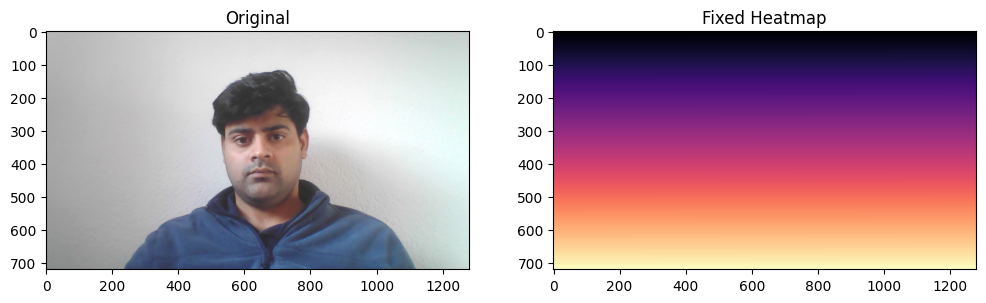

Opening 3D Viewer... Rotate the scene to see the depth!


In [5]:
import os
import torch
import cv2
import numpy as np
import open3d as o3d
import matplotlib.pyplot as plt
from tkinter import Tk, filedialog

# ==========================================
# 1. FILE PICKER
# ==========================================
def select_file():
    root = Tk()
    root.withdraw()
    root.attributes('-topmost', True)
    path = filedialog.askopenfilename()
    root.destroy()
    return path

img_path = select_file()
raw_image = cv2.imread(img_path)
raw_image_rgb = cv2.cvtColor(raw_image, cv2.COLOR_BGR2RGB)
h, w = raw_image.shape[:2]

# ==========================================
# 2. DEPTH GENERATION (WITH NORMALIZATION)
# ==========================================
# --- RE-RUN YOUR DA-V2 INFERENCE HERE ---
# depth = model.infer_image(raw_image_rgb) 

# IMPORTANT: Stretch the depth map so we see the heatmap detail
depth_min = depth.min()
depth_max = depth.max()
depth_normalized = (depth - depth_min) / (depth_max - depth_min + 1e-8)

# ==========================================
# 3. 3DGS EXPORT (WITH DEPTH STRETCHING)
# ==========================================
def create_3dgs_ply(rgb, depth_norm, output_path="output_gs.ply"):
    rows, cols = depth_norm.shape
    c, r = np.meshgrid(np.arange(cols), np.arange(rows))
    
    # PARAMETERS TO FIX "FLATNESS"
    focal_length = cols  # Adjusts perspective
    depth_intensity = 0.5 * cols # STRETCHES the Z-axis for 3D effect
    
    # Use the normalized depth to create Z
    # We invert it (1.0 - depth) if the model gave us disparity
    z = (1.0 - depth_norm) * depth_intensity 
    
    x = (c - cols / 2) * z / focal_length
    y = (r - rows / 2) * z / focal_length
    
    points = np.stack([x, y, z], axis=-1).reshape(-1, 3)
    colors = rgb.reshape(-1, 3) / 255.0
    
    # Remove extreme background (Optional)
    mask = depth_norm > 0.05 
    points = points[mask.flatten()]
    colors = colors[mask.flatten()]

    # Create Open3D Point Cloud
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(points)
    pcd.colors = o3d.utility.Vector3dVector(colors)
    pcd.estimate_normals()
    
    o3d.io.write_point_cloud(output_path, pcd)
    return pcd

pcd = create_3dgs_ply(raw_image_rgb, depth_normalized)

# ==========================================
# 4. VISUALIZATION
# ==========================================
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(raw_image_rgb)
plt.title("Original")

plt.subplot(1, 2, 2)
# We use 'magma' on the normalized depth to ensure we see the heat
plt.imshow(depth_normalized, cmap='magma') 
plt.title("Fixed Heatmap")
plt.show()

print("Opening 3D Viewer... Rotate the scene to see the depth!")
o3d.visualization.draw_geometries([pcd])